<a href="https://colab.research.google.com/github/WCosmo/AWGN_monte_carlo/blob/main/AWGN_monte_carlo_jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [111]:
# Nome: AWGN_monte_carlo_jupyter.ipynb
# Autor: Wilson Cosmo
# Data: 30/04/2026

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple, Dict
import time

In [113]:
# ------------------------------------------------------------------------------
# PARÂMETROS LORA
# ------------------------------------------------------------------------------

In [114]:
@dataclass
class LoRaParams:
    """Parâmetros físicos do transceptor LoRa"""
    freq_hz: float = 915.0e6        # Frequência central (Hz)
    sf: int = 7                      # Spreading Factor (6-12)
    bw_hz: float = 125.0e3          # Bandwidth (Hz)
    cr: int = 1                      # Coding Rate 4/(4+CR)
    preamble_len: int = 8            # Símbolos de preâmbulo

    @property
    def M(self) -> int:
        """Número de amostras por símbolo = 2^SF"""
        return 2 ** self.sf

    @property
    def Ts(self) -> float:
        """Duração do símbolo em segundos = M / BW"""
        return self.M / self.bw_hz

    @property
    def Ts_ms(self) -> float:
        return self.Ts * 1000.0

    @property
    def fs(self) -> float:
        """Taxa de amostragem baseband = BW"""
        return self.bw_hz

    @property
    def bitrate(self) -> float:
        """Taxa bruta de bits = SF * BW / 2^SF"""
        return self.sf * self.bw_hz / self.M

In [115]:
@dataclass
class SimulationConfig:
    """Configuração da simulação Monte Carlo"""
    N: int = 100                     # Número de pacotes (realizações)
    T: int = 100                     # Tamanho do pacote em bytes
    IT: int = 30000                  # Intervalo entre pacotes (ms)
    IR: float = -5.0                 # Intensidade do Ruído (SNR em dB)
    lora: LoRaParams = None
    seed: int = 42                   # Seed para reprodutibilidade

    def __post_init__(self):
        if self.lora is None:
            self.lora = LoRaParams()

In [116]:
# ------------------------------------------------------------------------------
# MODULADOR LORA CSS
# ------------------------------------------------------------------------------

In [117]:
class LoRaModulator:
    """
    Modulador LoRa CSS (Chirp Spread Spectrum).
    Gera chirps up com deslocamento de frequência proporcional ao símbolo.
    """

    def __init__(self, params: LoRaParams):
        self.p = params

    def generate_chirp(self, symbol: int, inverse: bool = False) -> np.ndarray:
        """
        Gera um chirp LoRa para um símbolo (0 .. 2^SF - 1).

        Fórmula da fase instantânea:
        - Up-chirp:   φ(t) = 2π * [(-BW/2 + symbol·BW/M)·t + (BW/(2·Ts))·t²]
        - Down-chirp: φ(t) = 2π * [(+BW/2)·t - (BW/(2·Ts))·t²]
        """
        M = self.p.M
        Ts = self.p.Ts
        BW = self.p.bw_hz
        fs = self.p.fs

        t = np.arange(M) / fs

        if inverse:
            # Down-chirp de referência (usado na demodulação)
            phi = 2 * np.pi * ((BW / 2) * t - (BW / (2 * Ts)) * t**2)
        else:
            # Up-chirp com deslocamento do símbolo
            f0 = -BW / 2 + (symbol * BW / M)
            phi = 2 * np.pi * (f0 * t + (BW / (2 * Ts)) * t**2)

        return np.exp(1j * phi)

    def modulate_packet(self, data_bytes: bytes) -> Tuple[np.ndarray, List[int], int]:
        """
        Modula um pacote de bytes em uma sequência de chirps LoRa.

        Returns:
            sinal_complexo, lista_de_simbolos, n_bits_originais
        """
        bits = np.unpackbits(np.frombuffer(data_bytes, dtype=np.uint8))
        n_bits_orig = len(bits)
        sf = self.p.sf

        # Agrupa bits em símbolos de SF bits cada
        n_symbols = int(np.ceil(n_bits_orig / sf))
        if n_bits_orig % sf != 0:
            bits = np.pad(bits, (0, sf - (n_bits_orig % sf)), mode='constant')

        tx_symbols = []
        for i in range(n_symbols):
            sym_bits = bits[i*sf : (i+1)*sf]
            sym_val = int(np.dot(sym_bits, 2**np.arange(sf-1, -1, -1)))
            tx_symbols.append(sym_val)

        # Préâmbulo: chirps com símbolo 0
        preamble = [self.generate_chirp(0) for _ in range(self.p.preamble_len)]

        # Payload: chirps modulados pelos símbolos
        payload = [self.generate_chirp(sym) for sym in tx_symbols]

        packet_signal = np.concatenate(preamble + payload)
        return packet_signal, tx_symbols, n_bits_orig

In [118]:
# ------------------------------------------------------------------------------
# DEMODULADOR LORA
# ------------------------------------------------------------------------------

In [119]:
class LoRaDemodulator:
    """
    Demodulador LoRa via de-chirping (multiplicação por down-chirp + FFT).
    """

    def __init__(self, params: LoRaParams):
        self.p = params
        self.mod = LoRaModulator(params)

    def demodulate_symbol(self, rx_chirp: np.ndarray) -> int:
        """
        Demodula um único símbolo recebido.

        Processo:
        1. Multiplica pelo down-chirp de referência
        2. Aplica FFT
        3. Detecta o bin de frequência com maior energia
        """
        down_chirp = self.mod.generate_chirp(0, inverse=True)
        dechirped = rx_chirp * down_chirp
        fft_mag = np.abs(np.fft.fft(dechirped))
        detected = int(np.argmax(fft_mag))
        return detected

    def demodulate_packet(self, rx_signal: np.ndarray, n_symbols: int, n_bits_orig: int) -> Tuple[bytes, List[int]]:
        """
        Demodula o pacote recebido completo.

        Args:
            rx_signal: sinal complexo recebido do canal
            n_symbols: número de símbolos de payload esperados
            n_bits_orig: número de bits originais (para descartar padding)

        Returns:
            bytes demodulados, lista de símbolos detectados
        """
        M = self.p.M
        pre_samples = self.p.preamble_len * M
        payload_signal = rx_signal[pre_samples:]

        rx_symbols = []
        for i in range(n_symbols):
            start = i * M
            end = start + M
            if end > len(payload_signal):
                break
            rx_symbols.append(self.demodulate_symbol(payload_signal[start:end]))

        # Converte símbolos de volta para bits
        sf = self.p.sf
        bits = []
        for sym in rx_symbols:
            for b in range(sf-1, -1, -1):
                bits.append((sym >> b) & 1)

        # Mantém apenas os bits originais (remove padding de modulação)
        bits = bits[:n_bits_orig]
        n_bytes = int(np.ceil(len(bits) / 8))
        if len(bits) % 8 != 0:
            bits += [0] * (8 - len(bits) % 8)

        bit_arr = np.array(bits[:n_bytes*8], dtype=np.uint8)
        return np.packbits(bit_arr).tobytes(), rx_symbols

In [120]:
# ------------------------------------------------------------------------------
# CANAL AWGN
# ------------------------------------------------------------------------------

In [121]:
class AWGNChannel:
    """
    Canal com ruído branco gaussiano aditivo (AWGN).
    Adiciona ruído complexo circularmente simétrico com potência controlada pelo SNR.
    """

    def __init__(self, snr_db: float):
        self.snr_db = snr_db

    def add_noise(self, signal: np.ndarray) -> np.ndarray:
        """
        Adiciona ruído AWGN ao sinal.

        SNR = 10·log10(Ps / Pn)  =>  Pn = Ps / 10^(SNR/10)
        """
        Ps = np.mean(np.abs(signal)**2)
        snr_lin = 10 ** (self.snr_db / 10)
        Pn = Ps / snr_lin

        # Ruído complexo circularmente simétrico
        noise_real = np.random.normal(0, np.sqrt(Pn/2), len(signal))
        noise_imag = np.random.normal(0, np.sqrt(Pn/2), len(signal))
        noise = noise_real + 1j * noise_imag

        return signal + noise

In [122]:
# ------------------------------------------------------------------------------
# SIMULADOR MONTE CARLO
# ------------------------------------------------------------------------------

In [123]:
class LoRaMonteCarloSimulator:
    """
    Simulador Monte Carlo completo de canal LoRa P2P.
    Executa N transmissões independentes e estima BER e PDR estatisticamente.
    """

    def __init__(self, config: SimulationConfig):
        self.cfg = config
        self.lora = config.lora
        np.random.seed(config.seed)

        self.mod = LoRaModulator(self.lora)
        self.demod = LoRaDemodulator(self.lora)
        self.channel = AWGNChannel(config.IR)

        # Estatísticas
        self.total_bits = 0
        self.error_bits = 0
        self.packets_sent = 0
        self.packets_ok = 0
        self.packets_corrupt = 0

        # Históricos para análise de convergência
        self.ber_history = []
        self.per_history = []
        self.packet_results = []

    def simulate_packet(self, data: bytes) -> Tuple[bytes, int, bool]:
        """
        Simula uma transmissão completa de um pacote.

        Returns:
            bytes_recebidos, bit_errors, is_intact
        """
        # 1. MODULAÇÃO
        tx_sig, tx_syms, n_bits = self.mod.modulate_packet(data)

        # 2. CANAL AWGN
        rx_sig = self.channel.add_noise(tx_sig)

        # 3. DEMODULAÇÃO
        rx_bytes, rx_syms = self.demod.demodulate_packet(rx_sig, len(tx_syms), n_bits)

        # 4. COMPARAÇÃO (apenas bytes originais)
        min_len = min(len(rx_bytes), len(data))
        tx_bits = np.unpackbits(np.frombuffer(data[:min_len], dtype=np.uint8))
        rx_bits = np.unpackbits(np.frombuffer(rx_bytes[:min_len], dtype=np.uint8))

        bit_errors = int(np.sum(rx_bits != tx_bits))
        if len(rx_bytes) < len(data):
            bit_errors += (len(data) - len(rx_bytes)) * 8

        is_intact = (bit_errors == 0)

        return rx_bytes, bit_errors, is_intact

    def run(self, verbose: bool = True) -> Dict:
        """
        Executa simulação Monte Carlo de N pacotes.

        Returns:
            Dicionário com métricas e históricos.
        """
        if verbose:
            print("=" * 70)
            print("SIMULAÇÃO MONTE CARLO - CANAL LORA P2P COM AWGN")
            print("=" * 70)
            print(f"\nParâmetros LoRa:")
            print(f"   Frequência:     {self.lora.freq_hz/1e6:.1f} MHz")
            print(f"   SF:             {self.lora.sf}")
            print(f"   BW:             {self.lora.bw_hz/1e3:.1f} kHz")
            print(f"   Amostras/sym:   {self.lora.M}")
            print(f"   Duração sym:    {self.lora.Ts_ms:.2f} ms")
            print(f"   Taxa:           {self.lora.bitrate:.0f} bps")
            print(f"\nMonte Carlo:")
            print(f"   N (pacotes):    {self.cfg.N}")
            print(f"   T (bytes):      {self.cfg.T} ({self.cfg.T*8} bits)")
            print(f"   IT (ms):        {self.cfg.IT}")
            print(f"   IR (SNR dB):    {self.cfg.IR}")
            print(f"   Seed:           {self.cfg.seed}")
            print(f"\nIniciando {self.cfg.N} realizações...\n")

        t0 = time.time()

        for i in range(self.cfg.N):
            pkt = np.random.bytes(self.cfg.T)
            _, err, intact = self.simulate_packet(pkt)

            self.total_bits += self.cfg.T * 8
            self.error_bits += err
            self.packets_sent += 1

            if intact:
                self.packets_ok += 1
            else:
                self.packets_corrupt += 1

            ber = self.error_bits / self.total_bits
            per = self.packets_corrupt / self.packets_sent
            self.ber_history.append(ber)
            self.per_history.append(per)
            self.packet_results.append({
                'seq': i+1, 'errors': err, 'intact': intact, 'ber': ber, 'per': per
            })

            if verbose and (i+1) % max(1, self.cfg.N // 10) == 0:
                print(f"   [{i+1:3d}/{self.cfg.N}] BER={ber:.2e} | "
                      f"OK={self.packets_ok:3d} | ERR={self.packets_corrupt:3d}")

        elapsed = time.time() - t0

        ber = self.error_bits / self.total_bits
        per = self.packets_corrupt / self.packets_sent
        pdr = self.packets_ok / self.packets_sent

        results = {
            'config': {
                'N': self.cfg.N, 'T': self.cfg.T, 'IT': self.cfg.IT, 'IR': self.cfg.IR,
                'SF': self.lora.sf, 'freq_MHz': self.lora.freq_hz/1e6,
                'bw_kHz': self.lora.bw_hz/1e3
            },
            'total_bits': self.total_bits,
            'error_bits': self.error_bits,
            'ber': ber,
            'per': per,
            'pdr': pdr,
            'packets_sent': self.packets_sent,
            'packets_ok': self.packets_ok,
            'packets_corrupt': self.packets_corrupt,
            'elapsed': elapsed,
            'ber_history': self.ber_history,
            'per_history': self.per_history,
            'packet_results': self.packet_results
        }

        if verbose:
            self._print_summary(results, elapsed)
        return results

    def _print_summary(self, r: Dict, elapsed: float):
        print(f"\n{'='*70}")
        print("RESULTADOS MONTE CARLO")
        print(f"{'='*70}")
        print(f"\nPacotes:")
        print(f"   Enviados:      {r['packets_sent']}")
        print(f"   OK (Intactos): {r['packets_ok']} ({r['pdr']*100:.1f}%)")
        print(f"   Corrompidos:   {r['packets_corrupt']} ({r['per']*100:.1f}%)")
        print(f"\nMétricas:")
        print(f"   BER: {r['ber']:.6f} ({r['ber']*100:.4f}%)")
        print(f"   PER: {r['per']:.4f} ({r['per']*100:.2f}%)")
        print(f"   PDR: {r['pdr']:.4f} ({r['pdr']*100:.2f}%)")
        print(f"\nBits: Tx={r['total_bits']:,}  Err={r['error_bits']:,}")
        print(f"Tempo: {elapsed:.2f} s")

        pdr = r['pdr']
        if pdr >= 0.98: status = "EXCELENTE"
        elif pdr >= 0.90: status = "BOM"
        elif pdr >= 0.70: status = "REGULAR"
        elif pdr >= 0.30: status = "RUIM"
        else: status = "CRÍTICO"
        print(f"\nAvaliação (SF{r['config']['SF']}, SNR={r['config']['IR']}dB): {status}")

In [124]:
# ------------------------------------------------------------------------------
# VISUALIZAÇÃO
# ------------------------------------------------------------------------------

In [125]:
def plot_mc_results(results: Dict, figsize=(14, 10)):
    """Plota gráficos dos resultados Monte Carlo"""
    cfg = results['config']
    N = cfg['N']

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(
        f"Monte Carlo LoRa | SF{cfg['SF']} @ {cfg['freq_MHz']:.0f}MHz | SNR={cfg['IR']}dB | N={N}",
        fontsize=13, fontweight='bold', y=0.98
    )

    pkts = range(1, N + 1)

    # BER acumulado
    ax = axes[0, 0]
    ax.plot(pkts, results['ber_history'], 'b-', lw=1.2, label='BER acumulado')
    ax.axhline(y=results['ber'], color='r', ls='--', label=f"BER final: {results['ber']:.2e}")
    ax.set_xlabel('Realização (Pacote)')
    ax.set_ylabel('BER')
    ax.set_title('Convergência do BER')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    # PER acumulado
    ax = axes[0, 1]
    ax.plot(pkts, results['per_history'], 'r-', lw=1.2, label='PER acumulado')
    ax.axhline(y=results['per'], color='b', ls='--', label=f"PER final: {results['per']:.4f}")
    ax.set_xlabel('Realização (Pacote)')
    ax.set_ylabel('PER')
    ax.set_title('Convergência do PER')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

    # Histograma de erros
    ax = axes[1, 0]
    errs = [p['errors'] for p in results['packet_results'] if p['errors'] > 0]
    if errs:
        ax.hist(errs, bins=min(20, len(errs)), color='coral', edgecolor='black', alpha=0.8)
        ax.set_title(f'Distribuição de Erros (n={len(errs)} pacotes com erro)')
    else:
        ax.text(0.5, 0.5, 'Sem erros! Canal perfeito.', transform=ax.transAxes,
                ha='center', va='center', fontsize=14, color='green', fontweight='bold')
        ax.set_title('Distribuição de Erros')
    ax.set_xlabel('Bits Errados por Pacote')
    ax.set_ylabel('Frequência')
    ax.grid(True, alpha=0.3)

    # Resumo de entrega
    ax = axes[1, 1]
    vals = [results['packets_ok'], results['packets_corrupt']]
    bars = ax.bar(['Recebidos\n(Intactos)', 'Corrompidos'], vals,
                  color=['#27ae60', '#e74c3c'], edgecolor='black', width=0.6)
    ax.set_ylabel('Pacotes')
    ax.set_title('Entrega de Pacotes')
    ax.set_ylim(0, max(vals) * 1.2 + 1)
    for bar, val in zip(bars, vals):
        pct = val / N * 100
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f'{val}\n({pct:.1f}%)', ha='center', va='bottom',
                fontweight='bold', fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [126]:
def run_mc_sweep(snr_list: List[float], base_config: SimulationConfig):
    """
    Varredura de SNR usando simulação Monte Carlo.
    Útil para traçar curvas de desempenho do LoRa.
    """
    sweep = []
    print("\n" + "="*70)
    print("VARREDURA MONTE CARLO DE SNR")
    print("="*70)
    print(f"{'SNR (dB)':>10} | {'BER':>12} | {'PDR':>8} | {'OK':>6} | {'Tempo(s)':>8}")
    print("-" * 70)

    for snr in snr_list:
        # Seed sempre positiva
        seed = abs(base_config.seed + hash(str(snr)) % 100000)
        cfg = SimulationConfig(
            N=base_config.N, T=base_config.T, IT=base_config.IT,
            IR=snr, lora=base_config.lora, seed=seed
        )
        sim = LoRaMonteCarloSimulator(cfg)
        res = sim.run(verbose=False)
        sweep.append({'snr': snr, **res})
        print(f"{snr:>+10.1f} | {res['ber']:>12.2e} | {res['pdr']:>8.2%} | "
              f"{res['packets_ok']:>6d} | {res['elapsed']:>8.2f}")

    # Plot comparativo
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"Desempenho Monte Carlo vs SNR - SF{base_config.lora.sf}",
                 fontsize=13, fontweight='bold')

    snrs = [s['snr'] for s in sweep]

    ax1.semilogy(snrs, [s['ber'] for s in sweep], 'bo-', lw=2, ms=8)
    ax1.set_xlabel('SNR (dB) - IR')
    ax1.set_ylabel('BER')
    ax1.set_title('BER vs Intensidade do Ruído')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(1e-3, color='r', ls='--', alpha=0.5, label='BER = 10⁻³')
    ax1.legend()

    ax2.plot(snrs, [s['pdr'] for s in sweep], 'gs-', lw=2, ms=8)
    ax2.set_xlabel('SNR (dB) - IR')
    ax2.set_ylabel('Packet Delivery Rate')
    ax2.set_title('PDR vs Intensidade do Ruído')
    ax2.set_ylim(-0.05, 1.05)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(0.95, color='r', ls='--', alpha=0.5, label='PDR = 95%')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return sweep

In [127]:
# ================================================================
# EXEMPLO DE USO NO JUPYTER
# ================================================================

SIMULAÇÃO MONTE CARLO - CANAL LORA P2P COM AWGN

Parâmetros LoRa:
   Frequência:     915.0 MHz
   SF:             7
   BW:             125.0 kHz
   Amostras/sym:   128
   Duração sym:    1.02 ms
   Taxa:           6836 bps

Monte Carlo:
   N (pacotes):    100
   T (bytes):      100 (800 bits)
   IT (ms):        30000
   IR (SNR dB):    -8.0
   Seed:           42

Iniciando 100 realizações...

   [ 10/100] BER=0.00e+00 | OK= 10 | ERR=  0
   [ 20/100] BER=3.13e-04 | OK= 19 | ERR=  1
   [ 30/100] BER=5.00e-04 | OK= 27 | ERR=  3
   [ 40/100] BER=3.75e-04 | OK= 37 | ERR=  3
   [ 50/100] BER=5.25e-04 | OK= 44 | ERR=  6
   [ 60/100] BER=4.79e-04 | OK= 53 | ERR=  7
   [ 70/100] BER=5.18e-04 | OK= 62 | ERR=  8
   [ 80/100] BER=6.09e-04 | OK= 70 | ERR= 10
   [ 90/100] BER=8.75e-04 | OK= 74 | ERR= 16
   [100/100] BER=8.25e-04 | OK= 83 | ERR= 17

RESULTADOS MONTE CARLO

Pacotes:
   Enviados:      100
   OK (Intactos): 83 (83.0%)
   Corrompidos:   17 (17.0%)

Métricas:
   BER: 0.000825 (0.0825%)
  

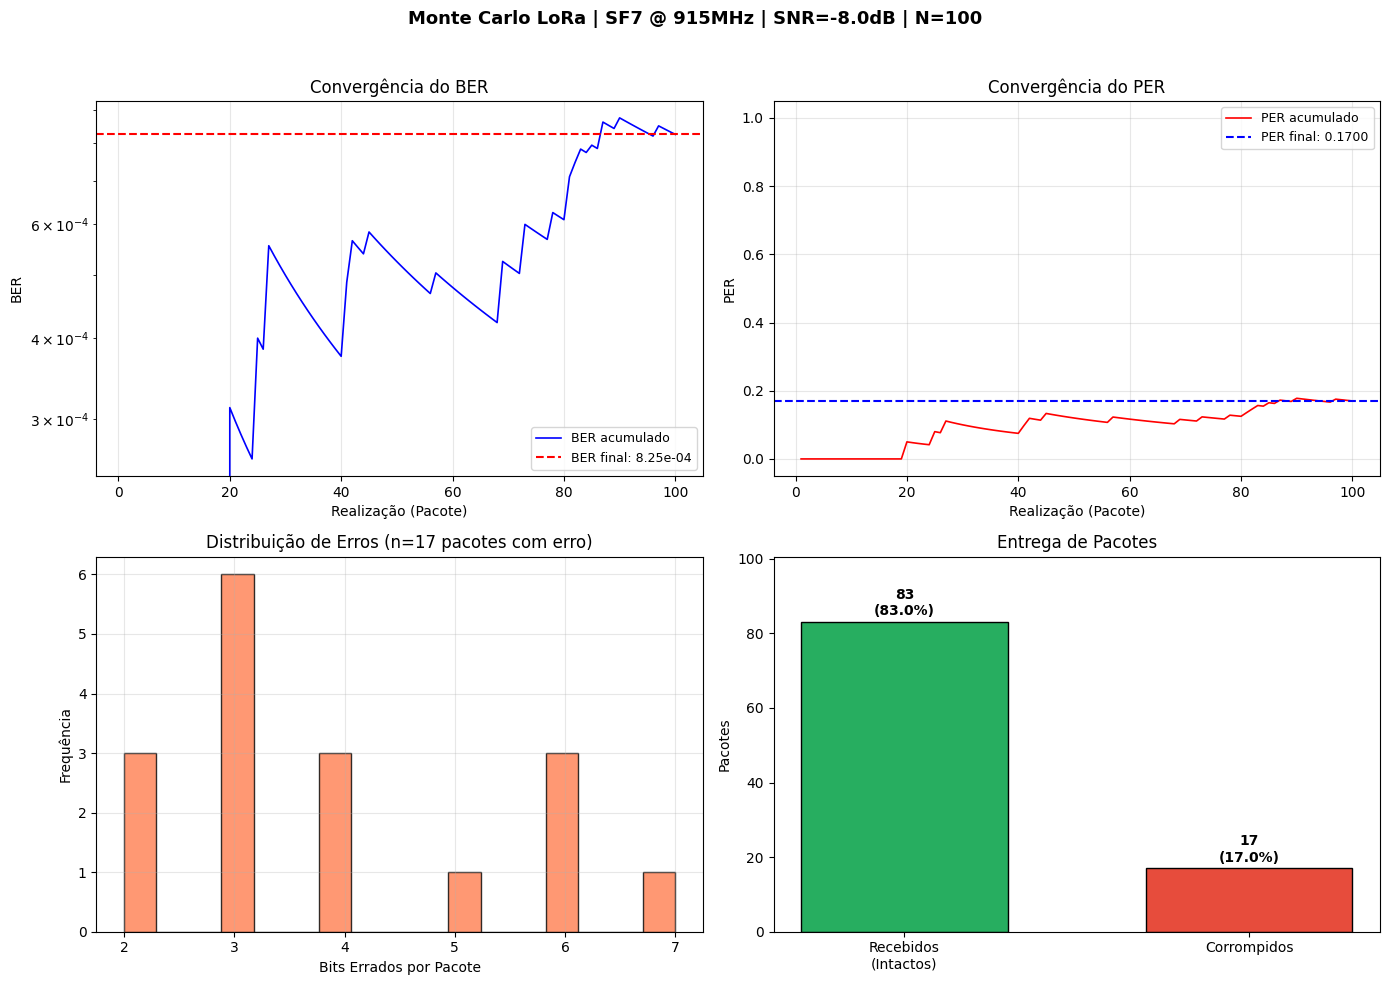

In [128]:
if __name__ == "__main__":

    # ================================================================
    # CONFIGURAÇÃO DO USUÁRIO
    # ================================================================

    CONFIG = SimulationConfig(
        N=100,              # Número de pacotes (realizações Monte Carlo)
        T=100,              # Tamanho do pacote em bytes
        IT=30000,           # Intervalo entre pacotes (ms)
        IR=-8.0,            # Intensidade do Ruído (SNR em dB)
                            #   Valores negativos = ruído > sinal
                            #   Valores positivos = sinal > ruído
        lora=LoRaParams(
            freq_hz=915e6,  # 915 MHz (banda AU)
            sf=7,           # Spreading Factor 7
            bw_hz=125e3,    # 125 kHz
            cr=1            # Coding Rate 4/5
        ),
        seed=42             # Seed para reprodutibilidade
    )

    # ================================================================
    # SIMULAÇÃO ÚNICA
    # ================================================================

    sim = LoRaMonteCarloSimulator(CONFIG)
    results = sim.run(verbose=True)
    plot_mc_results(results)

In [129]:
# ================================================================
# VARREDURA DE SNR (descomente para usar)
# ================================================================
# snr_values = [-20, -15, -12, -10, -8, -5, -2, 0, 2, 5, 10]
# sweep = run_mc_sweep(snr_values, CONFIG)